# Figure 2

One sentence reproduces the expert, ONT chromosome 20.

The cell below is `scripts/paper/make_panels.py` in full. It reads the per-run evaluation
records and writes several panels in one pass, so it is inlined once and the cells after it
show different panels from that run.

In [1]:
import sys; sys.path.insert(0, "../scripts"); sys.path.insert(0, "../scripts/paper")
from pathlib import Path
from nbkit import setup, paper_py, paper_r, run_r_source, harvest, show, have_r_package, DATA

OUT = setup("../figures/notebook")
print("panels will be written to", OUT)

# %%R cells below run R natively in this kernel through rpy2, so the R panels are R code
# in the notebook rather than a string that gets written to a file.
%load_ext rpy2.ipython

panels will be written to ./figures/notebook


## Figure 2b - the same evaluation applied to each arm

`human_upstream` is the expert's run, `agent_mcp_prompt` the agent's. In the paper each arm sits in its own dashed frame holding two plots; these are the right-hand one of each.

font: DejaVu Sans
{
  "font_used": "DejaVu Sans",
  "human": "human_upstream",
  "agents": [
    "agent_mcp_prompt"
  ],
  "tss_profile": {
    "agent_mcp_prompt": {
      "n_bins": 80,
      "pearson_r": 1.0,
      "rms_difference": 2.24e-06,
      "max_abs_difference": 1e-05
    }
  },
  "wgbs_by_coverage": {
    "agent_mcp_prompt": {
      "bins": 7,
      "max_abs_PCC_difference": 2.92e-06
    }
  }
}
panels -> ./data/runs/figure2/panels
12 panels collected


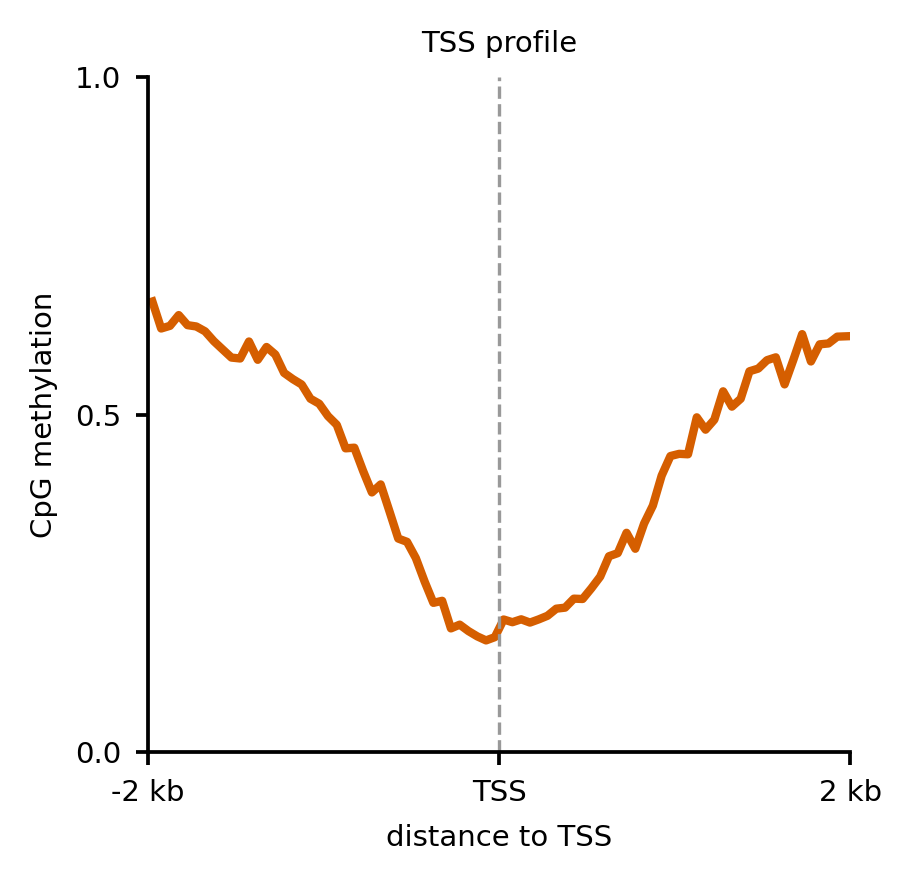

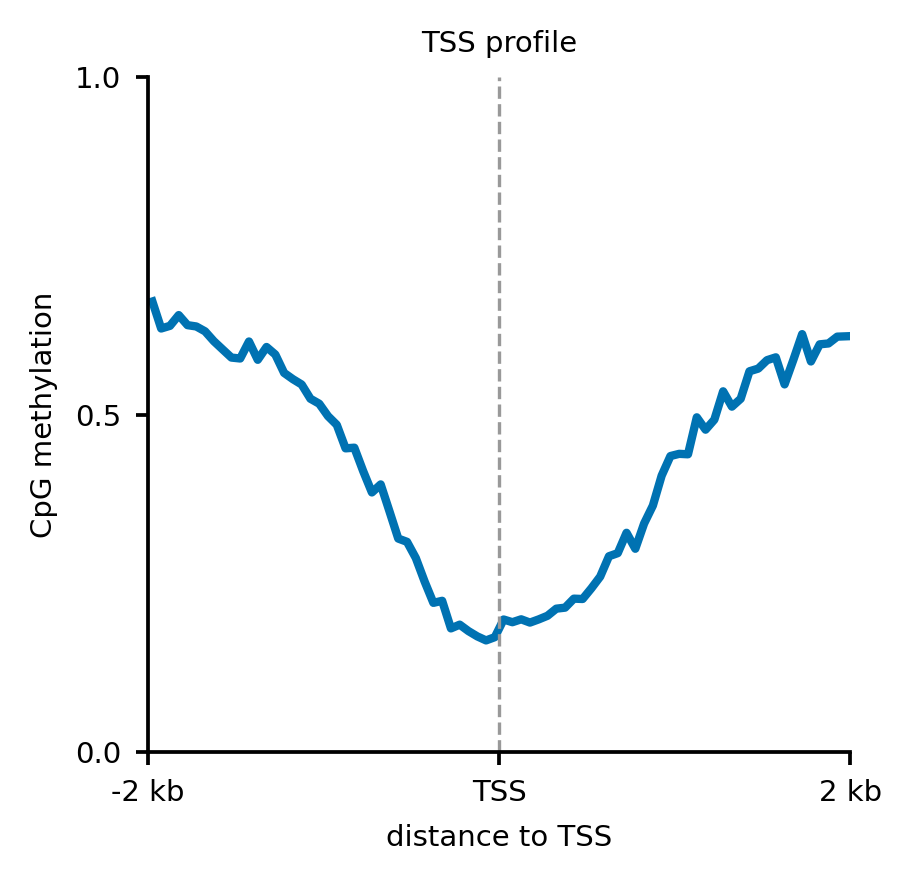

In [2]:
# scripts/paper/make_panels.py, inlined. sys.argv is what the paper passes it.
import sys
sys.argv = ['make_panels.py', 'figure2', 'human_upstream', 'agent_mcp_prompt']
__file__ = "../scripts/paper/make_panels.py"

"""Draw the data panels of New Figure 2 and New Figure 3 from the evaluation records.

One plotting function per panel type serves every arm, so anything visible is a difference
in the data and not in the drawing. Human on the left, agent on the right, without
exception. Each panel is written as PDF and PNG, and the numbers behind it as CSV.

Usage: 50_make_panels.py figure2|figure3 <human_label> <agent_label> [more agent labels]
"""
from __future__ import annotations

import csv
import json
import sys
import os
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import font_manager

sys.path.insert(0, str(Path(__file__).resolve().parent))
import panel_style

RUN = Path(os.environ.get("LV_RUN", "/project2/sli68423_1316/projects/long_verse/results/2026_09_25_longverse_agent_benchmark"))
EVAL = RUN / "evaluation"
FONT_DIR = Path(os.environ.get("LV_FONTS", "/project2/sli68423_1316/users/yang/software/fonts"))

FONT_USED = "DejaVu Sans"
for t in ("arial.ttf", "arialbd.ttf", "ariali.ttf"):
    if (FONT_DIR / t).is_file():
        font_manager.fontManager.addfont(str(FONT_DIR / t))
if (FONT_DIR / "arial.ttf").is_file():
    FONT_USED = "Arial"
panel_style.apply(plt, FONT_USED)
HUMAN_C, AGENT_C = "#D55E00", "#0072B2"
OTHER_C = ["#009E73", "#CC79A7", "#56B4E9"]


def load(label: str) -> dict:
    p = EVAL / f"{label}.json"
    if not p.is_file():
        raise SystemExit(f"missing evaluation record: {p}")
    return json.load(open(p))


def pearson(xs, ys):
    n = len(xs)
    mx, my = sum(xs) / n, sum(ys) / n
    sx = sum((v - mx) ** 2 for v in xs) ** 0.5
    sy = sum((v - my) ** 2 for v in ys) ** 0.5
    return (sum((xs[i] - mx) * (ys[i] - my) for i in range(n)) / (sx * sy)) if sx and sy else float("nan")


def prof(rec: dict) -> tuple[list, list]:
    m = rec["measurements"].get("tss_profile")
    if not m or not m.get("ok"):
        return [], []
    pts = m["payload"]["profile"]
    return [p["position_bp"] for p in pts], [p["mean_methylation"] for p in pts]


def draw_profile(ax, x, y, colour, title, compact: bool = False):
    """`compact` is for the single-arm panels, which are small and carry 12 pt type.

    Five tick labels and the words "mean CpG methylation" do not fit beside a 2.5 inch
    axis at 12 pt; three ticks and "CpG methylation" do. Nothing is shortened on the
    combined panel, which has the width for it.
    """
    ax.plot(x, y, color=colour, lw=2.0)
    ax.axvline(0, color="0.6", lw=0.8, ls="--")
    ax.set_xlim(min(x), max(x)); ax.set_ylim(0, 1)
    if compact:
        ax.set_xticks([-2000, 0, 2000])
        ax.set_xticklabels(["-2 kb", "TSS", "2 kb"])
        ax.set_yticks([0, 0.5, 1.0])
        ax.set_xlabel("distance to TSS"); ax.set_ylabel("CpG methylation")
    else:
        ax.set_xticks([-2000, -1000, 0, 1000, 2000])
        ax.set_xticklabels(["-2 kb", "-1 kb", "TSS", "1 kb", "2 kb"])
        ax.set_xlabel("distance to TSS"); ax.set_ylabel("mean CpG methylation")
    ax.set_title(title)


def panel_tss(out: Path, src: Path, human: dict, agents: list[dict]) -> dict:
    hx, hy = prof(human)
    if not hx:
        return {}
    cols = 1 + len(agents)
    fig, axes = plt.subplots(1, cols, figsize=(2.7 * cols, 2.3), sharey=True)
    axes = [axes] if cols == 1 else list(axes)
    draw_profile(axes[0], hx, hy, HUMAN_C, "Human command line")
    stats = {}
    for i, a in enumerate(agents):
        ax_, ay = prof(a)
        n = min(len(hy), len(ay))
        d = [ay[j] - hy[j] for j in range(n)]
        r = pearson(hy[:n], ay[:n])
        stats[a["arm"]] = {"n_bins": n, "pearson_r": round(r, 6),
                           "rms_difference": round((sum(v * v for v in d) / n) ** 0.5, 8),
                           "max_abs_difference": round(max(abs(v) for v in d), 8)}
        draw_profile(axes[i + 1], ax_, ay, AGENT_C if i == 0 else OTHER_C[i % 3],
                     f"Agent ({a['arm'].replace('agent_', '')})")
        axes[i + 1].set_ylabel("")
        axes[i + 1].text(0.97, 0.06,
                         f"r = {stats[a['arm']]['pearson_r']:.6f}\n"
                         f"RMS diff = {stats[a['arm']]['rms_difference']:.2e}",
                         transform=axes[i + 1].transAxes, ha="right", va="bottom", fontsize=6.5)
    fig.tight_layout()
    for e in ("pdf", "png"):
        fig.savefig(out / f"panel_tss_profile.{e}")
    plt.close(fig)

    # The same profiles again, one file per arm, so panel c can be laid out with the person
    # on the left and the agent on the right instead of as one strip. Same axes limits and
    # same drawing function, so a difference between the two files is a difference in data.
    for tag, xs, ys_, colour, title in (
            [("human", hx, hy, HUMAN_C, "TSS profile")]
            + [(f"agent", *prof(a), AGENT_C, "TSS profile") for a in agents[:1]]):
        f1, a1 = plt.subplots(figsize=(3.05, 2.95))
        draw_profile(a1, xs, ys_, colour, title, compact=True)
        f1.tight_layout()
        for e in ("pdf", "png"):
            f1.savefig(out / f"panel_tss_{tag}.{e}")
        plt.close(f1)
    with open(src / "panel_tss_profile.csv", "w", newline="") as fh:
        w = csv.writer(fh)
        w.writerow(["position_bp", "human"] + [a["arm"] for a in agents])
        series = [prof(a)[1] for a in agents]
        for j, x in enumerate(hx):
            w.writerow([x, f"{hy[j]:.6f}"] + [f"{s[j]:.6f}" if j < len(s) else "" for s in series])
    return stats


def panel_wgbs(out: Path, src: Path, human: dict, agents: list[dict]) -> dict:
    def rows(rec):
        m = rec["measurements"].get("wgbs_by_coverage")
        if not m or not m.get("ok"):
            return []
        return [r for r in m["payload"].get("results", []) if r.get("tool") == "ont"
                and r.get("PCC") is not None]
    hr = rows(human)
    if not hr:
        return {}
    fig, ax = plt.subplots(figsize=(3.1, 2.3))
    ax.plot([r["cov_bin_mid"] for r in hr], [r["PCC"] for r in hr], "o-",
            color=HUMAN_C, lw=1.4, ms=4, label="Human command line")
    stats = {}
    for i, a in enumerate(agents):
        ar = rows(a)
        if not ar:
            continue
        ax.plot([r["cov_bin_mid"] for r in ar], [r["PCC"] for r in ar], "s--",
                color=AGENT_C if i == 0 else OTHER_C[i % 3], lw=1.2, ms=3.5,
                label=f"Agent ({a['arm'].replace('agent_','')})")
        n = min(len(hr), len(ar))
        stats[a["arm"]] = {"bins": n,
                           "max_abs_PCC_difference": round(max(abs(ar[j]["PCC"] - hr[j]["PCC"])
                                                               for j in range(n)), 8)}
    ax.set_xlabel("ONT coverage bin (midpoint)"); ax.set_ylabel("Pearson r against WGBS")
    ax.set_ylim(0, 1); ax.legend(frameon=False, loc="lower right")
    ax.set_title("Agreement with WGBS by coverage")
    fig.tight_layout()
    for e in ("pdf", "png"):
        fig.savefig(out / f"panel_wgbs_by_coverage.{e}")
    plt.close(fig)

    # One file per arm, drawn at the width it is placed at, for the two-row panel c. The
    # axis label is shortened because at 12 pt "Pearson r against WGBS" is wider than the
    # 2.4 inch axis it labels; the caption says what the axis is.
    for tag, rec, colour, marker in (("human", human, HUMAN_C, "o-"),
                                     ("agent", agents[0] if agents else None, AGENT_C, "s-")):
        if rec is None:
            continue
        rr = rows(rec)
        if not rr:
            continue
        f1, a1 = plt.subplots(figsize=(3.05, 2.95))
        a1.plot([r["cov_bin_mid"] for r in rr], [r["PCC"] for r in rr], marker,
                color=colour, lw=2.0, ms=6)
        a1.set_xlabel("ONT coverage")
        a1.set_ylabel("r against WGBS")
        a1.set_ylim(0, 1)
        a1.set_yticks([0, 0.5, 1.0])
        a1.set_title("By coverage")
        f1.tight_layout()
        for e in ("pdf", "png"):
            f1.savefig(out / f"panel_wgbs_cov_{tag}.{e}")
        plt.close(f1)
    with open(src / "panel_wgbs_by_coverage.csv", "w", newline="") as fh:
        w = csv.writer(fh); w.writerow(["arm", "cov_bin", "cov_bin_mid", "n_cpg", "PCC", "MSE"])
        for lbl, rec in [("human", human)] + [(a["arm"], a) for a in agents]:
            for r in rows(rec):
                w.writerow([lbl, r["cov_bin"], r["cov_bin_mid"], r["n_cpg"], r["PCC"], r["MSE"]])
    return stats


def panel_icr(out: Path, src: Path, human: dict, agents: list[dict]) -> dict:
    def regions(rec):
        m = rec["measurements"].get("icr_haplotypes")
        if not m or not m.get("ok"):
            return {}
        return {r["name"]: (r["HP1_avg"], r["HP2_avg"], r["start"]) for r in m["payload"]["regions"]}
    hr = regions(human)
    if not hr:
        return {}
    order = sorted(hr, key=lambda k: int(hr[k][2]))
    cols = 1 + len(agents)
    fig, axes = plt.subplots(1, cols, figsize=(2.9 * cols, 2.5), sharey=True)
    axes = [axes] if cols == 1 else list(axes)
    stats = {}
    for i, (lbl, rec, colour) in enumerate(
            [("Human command line", human, HUMAN_C)] +
            [(f"Agent ({a['arm'].replace('agent_','')})", a,
              AGENT_C if k == 0 else OTHER_C[k % 3]) for k, a in enumerate(agents)]):
        rg = regions(rec)
        ax = axes[i]
        for j, n in enumerate(order):
            v = rg.get(n)
            if not v or v[0] is None or v[1] is None:
                continue
            ax.plot([v[0], v[1]], [j, j], color="0.75", lw=0.8, zorder=1)
            ax.scatter([v[0]], [j], s=26, facecolor="white", edgecolor=colour, lw=1.1, zorder=3)
            ax.scatter([v[1]], [j], s=26, color=colour, zorder=3)
        ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=6.5)
        ax.set_xlim(-0.03, 1.03); ax.set_xlabel("mean CpG methylation")
        ax.set_title(lbl); ax.invert_yaxis()
        if i:
            ax.set_ylabel("")
            pairs = [(hr[n][k], rg[n][k]) for n in order if n in rg
                     for k in (0, 1) if hr[n][k] is not None and rg[n][k] is not None]
            if pairs:
                stats[agents[i - 1]["arm"]] = {
                    "values": len(pairs),
                    "pearson_r": round(pearson([p[0] for p in pairs], [p[1] for p in pairs]), 6),
                    "max_abs_difference": round(max(abs(p[1] - p[0]) for p in pairs), 8)}
    axes[0].scatter([], [], s=26, facecolor="white", edgecolor=HUMAN_C, lw=1.1, label="HP1")
    axes[0].scatter([], [], s=26, color=HUMAN_C, label="HP2")
    axes[0].legend(loc="lower right", frameon=False, fontsize=6.5)
    fig.tight_layout()
    for e in ("pdf", "png"):
        fig.savefig(out / f"panel_icr_haplotype.{e}")
    plt.close(fig)
    with open(src / "panel_icr_haplotype.csv", "w", newline="") as fh:
        w = csv.writer(fh); w.writerow(["region", "arm", "HP1", "HP2"])
        for lbl, rec in [("human", human)] + [(a["arm"], a) for a in agents]:
            rg = regions(rec)
            for n in order:
                v = rg.get(n)
                if v:
                    w.writerow([n, lbl, v[0], v[1]])
    return stats


def main() -> int:
    if len(sys.argv) < 4:
        print(__doc__.strip().splitlines()[-1], file=sys.stderr)
        return 2
    which, hlabel, alabels = sys.argv[1], sys.argv[2], sys.argv[3:]
    out = RUN / which / "panels"; out.mkdir(parents=True, exist_ok=True)
    src = RUN / which / "source_data"; src.mkdir(parents=True, exist_ok=True)
    human = load(hlabel); agents = [load(a) for a in alabels]
    for r, lbl in [(human, hlabel)] + list(zip(agents, alabels)):
        r["arm"] = lbl
    summary = {"font_used": FONT_USED, "human": hlabel, "agents": alabels}
    if which == "figure2":
        summary["tss_profile"] = panel_tss(out, src, human, agents)
        summary["wgbs_by_coverage"] = panel_wgbs(out, src, human, agents)
    else:
        summary["icr_haplotype"] = panel_icr(out, src, human, agents)
    (RUN / which / "concordance.json").write_text(json.dumps(summary, indent=2))
    print(f"font: {FONT_USED}")
    print(json.dumps(summary, indent=2))
    print(f"panels -> {out}")
    return 0

main()
print(harvest('fig2_ont'), "panels collected")
show("panel_tss_human.png", "panel_tss_agent.png", prefix='fig2_ont')

## The other half of Figure 2b, and what it is not

The left-hand plot in each frame is a per-site hexbin against the bisulfite reference. Its script, `scripts/paper/make_hexbin_panel.py`, reads both arms' whole chromosome-20 per-site tables and the 540 MB bisulfite table, which this repository does not carry, so that half is not drawn here. What is below comes from the same pass as the cell above and is the measurement Extended Data Fig. 1a makes, both arms in one plot.

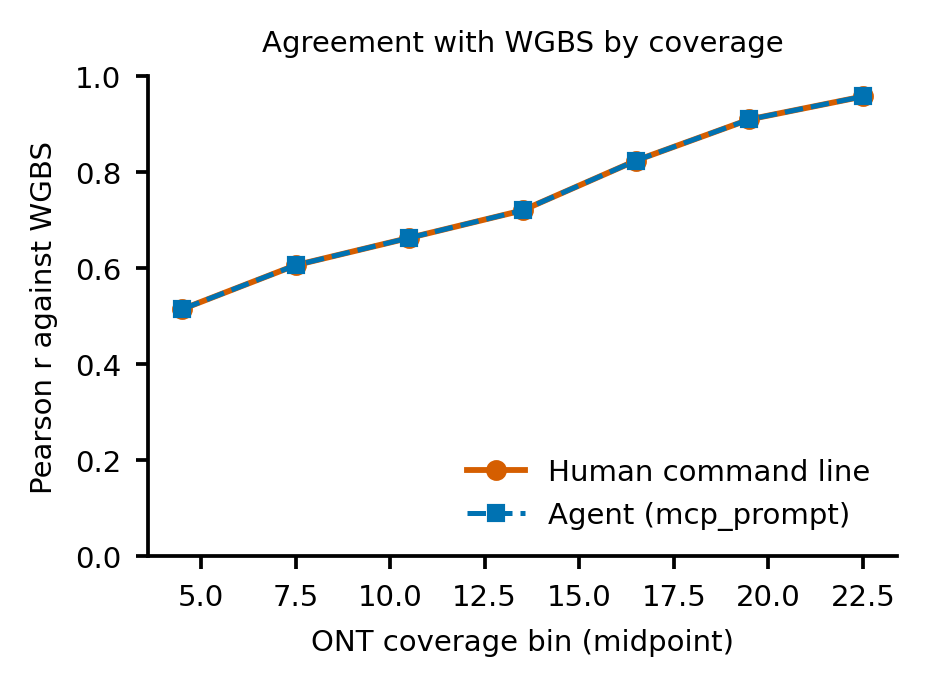

In [3]:
show("panel_wgbs_by_coverage.png", prefix="fig2_ont")

## Figure 2b - the other plot in each arm's frame, a per-site hexbin

Every chromosome 20 site each arm called, against the bisulfite reference. The paper runs this on the whole bisulfite table; here it is the chromosome 20 slice of it, 13 MB instead of 515, which is the same sites because the arms only called chromosome 20.

sites after filtering: human 1,575,278  agent 1,575,278  wgbs 1,597,303


overlaps: human-wgbs 1,540,012  agent-wgbs 1,540,012  human-agent 1,575,278


  wrote panel_hexbin_human_vs_wgbs


  wrote panel_hexbin_agent_vs_wgbs


  wrote panel_hexbin_human_vs_agent
wrote ./figures/notebook/panel_hexbin_vs_wgbs.pdf
wrote ./figures/source_data/panel_hexbin_vs_wgbs.csv
  human_vs_wgbs      r=0.942923  n=1,540,012
  agent_vs_wgbs      r=0.942923  n=1,540,012
  human_vs_agent     r=1.000000  n=1,575,278


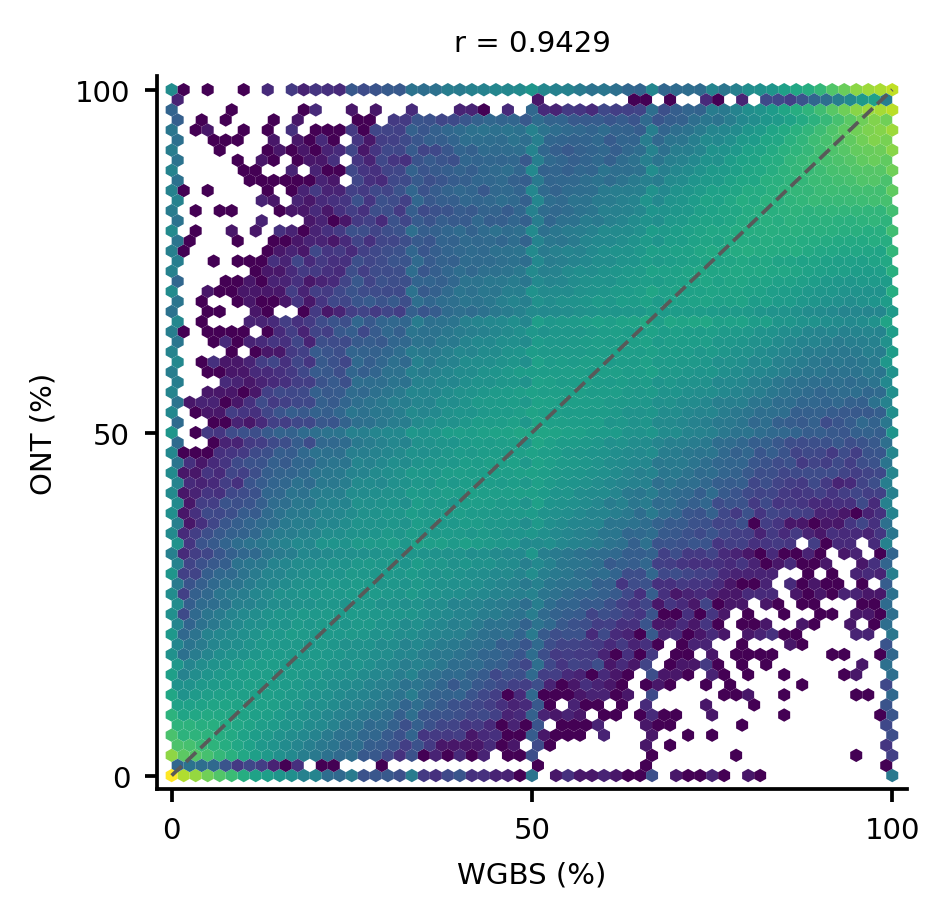

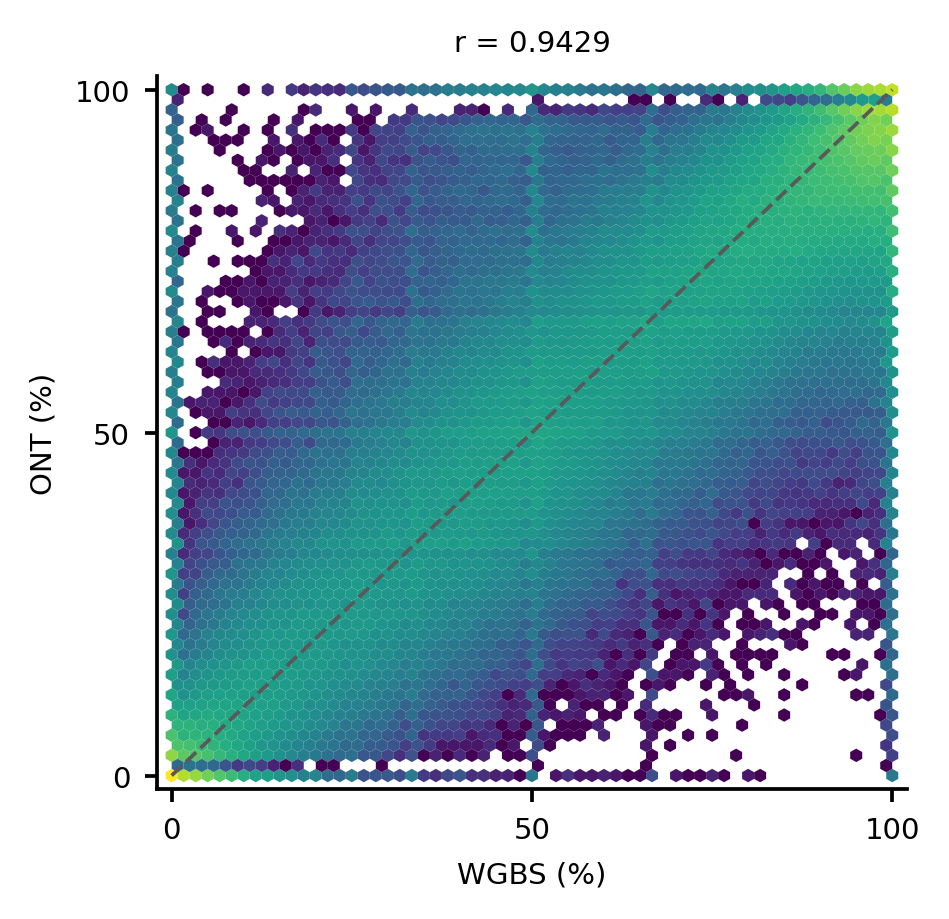

In [4]:
# scripts/paper/make_hexbin_panel.py, inlined. sys.argv is what the paper passes it.
import sys
sys.argv = ['make_hexbin_panel.py', f'{DATA}/hexbin_chr20/ont_human_chr20_persite_cov1.bed.gz', f'{DATA}/hexbin_chr20/ont_agent_chr20_persite_cov1.bed.gz', f'{DATA}/hexbin_chr20/wgbs_chr20.bismark.cov.gz', f'{OUT}']
__file__ = "../scripts/paper/make_hexbin_panel.py"

"""Panel C of New Figure 2: per-site methylation agreement, as hexbin scatter.

This replaces the earlier "agreement by coverage" curve. That curve reported one
correlation per coverage bin, which compressed 1.6 million sites into seven numbers and
hid both the shape of the agreement and the sites that disagree. A hexbin scatter shows
every site and still reads at figure size, and a single Pearson r per panel is the number
the reader wants.

Three panels, drawn by one function so that anything visible is a difference in the data
and not in the drawing:

    human command line  vs WGBS      does the person's run agree with the orthogonal assay
    agent               vs WGBS      does the agent's run agree with it equally well
    human               vs agent     do the two arms agree with each other

The third is the one that answers "did the agent drive the pipeline correctly", and it is
the strictest of the three: WGBS is a different assay on different molecules, so perfect
agreement with it is not expected from anyone, while the two arms ran the same pipeline on
the same reads with the same model and should be identical.

Frozen parameters, as agreed for the manuscript:
    WGBS            no coverage filter
    long read       min coverage 5
    strands         not merged; each strand-specific CpG is its own point

Joining on position alone is unambiguous here precisely because strands are not merged:
the + and - site of a CpG sit at different coordinates in both file types.

Usage:
    53_make_hexbin_panel.py <human_perSite.bed.gz> <agent_perSite.bed.gz> <wgbs.cov.gz> <outdir>
"""
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager

sys.path.insert(0, str(Path(__file__).resolve().parent))
import panel_style
from matplotlib.colors import LogNorm
from scipy import stats

FONT_DIR = Path(os.environ.get("LV_FONTS", "/project2/sli68423_1316/users/yang/software/fonts"))
FONT_USED = "DejaVu Sans"
for t in ("arial.ttf", "arialbd.ttf", "ariali.ttf"):
    if (FONT_DIR / t).is_file():
        font_manager.fontManager.addfont(str(FONT_DIR / t))
if (FONT_DIR / "arial.ttf").is_file():
    FONT_USED = "Arial"
panel_style.apply(plt, FONT_USED)

MIN_COV_LONGREAD = 5
GRIDSIZE = 60


def load_persite(path: Path, name: str) -> pd.DataFrame:
    """nanome per-site BED: chrom, start0, end, ., ., strand, methfreq(0-1), coverage."""
    df = pd.read_csv(path, sep="\t", header=None, compression="gzip",
                     usecols=[0, 1, 5, 6, 7],
                     names=["chrom", "start0", "strand", "freq", "cov"])
    df["pos"] = df["start0"] + 1              # to 1-based, matching the WGBS file
    df = df[df["cov"] >= MIN_COV_LONGREAD]
    df[name] = df["freq"] * 100.0             # to percent, matching the WGBS file
    return df[["chrom", "pos", name]]


def load_wgbs(path: Path, name: str) -> pd.DataFrame:
    """Bismark coverage: chrom, start1, end1, percent, n_methylated, n_unmethylated.

    No coverage filter is applied, by agreement. Column 4 is already a percentage, so it
    is used as it stands rather than recomputed from columns 5 and 6.
    """
    df = pd.read_csv(path, sep="\t", header=None, compression="gzip",
                     usecols=[0, 1, 3], names=["chrom", "pos", name])
    return df


def panel(ax, x, y, xlabel, ylabel, title, norm=None):
    """Draw one hexbin. `norm` is passed in so panels that share a colour bar share a scale.

    Each hexbin would otherwise build its own LogNorm from its own counts, and a single
    colour bar next to three such panels would describe only the first of them. The two
    WGBS panels are the ones a reader compares directly, so they are given one shared norm
    and one colour bar; the human-vs-agent panel concentrates the same number of sites onto
    a diagonal, reaching per-bin counts an order of magnitude higher, so forcing it onto
    that scale would saturate it. It gets its own colour bar instead.
    """
    r, p = stats.pearsonr(x, y)
    hb = ax.hexbin(x, y, gridsize=GRIDSIZE, bins=None, norm=norm or LogNorm(),
                   cmap="viridis", mincnt=1, linewidths=0)
    ax.plot([0, 100], [0, 100], color="0.35", lw=0.6, ls="--", zorder=3)
    ax.set_xlim(-2, 102)
    ax.set_ylim(-2, 102)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    # The correlation goes in the title rather than in a box inside the axes. A boxed
    # annotation was tried first and placed bottom right, but in the two WGBS panels that
    # corner is not empty: it holds the sites WGBS calls methylated and the long reads do
    # not, which are exactly the sites a reader looks for. Covering them to display a
    # number that has no position on the axes was the wrong trade.
    ax.set_title(f"{title}\nr = {r:.4f}, n = {len(x):,}", pad=4, fontsize=8)
    return hb, r, p, len(x)


def main() -> int:
    if len(sys.argv) != 5:
        print(__doc__)
        return 2
    human_p, agent_p, wgbs_p, outdir = (Path(a) for a in sys.argv[1:5])
    # The two arms used different basecalling models, and that is the whole reason the
    # third panel is a cloud rather than a line. Naming the model on the axis keeps a
    # reader from reading the spread as agent error.
    hlab = os.environ.get("HUMAN_LABEL", "Human command line")
    alab = os.environ.get("AGENT_LABEL", "Agent")
    outdir.mkdir(parents=True, exist_ok=True)

    human = load_persite(human_p, "human")
    agent = load_persite(agent_p, "agent")
    wgbs = load_wgbs(wgbs_p, "wgbs")
    print(f"sites after filtering: human {len(human):,}  agent {len(agent):,}  wgbs {len(wgbs):,}")

    hw = human.merge(wgbs, on=["chrom", "pos"], how="inner")
    aw = agent.merge(wgbs, on=["chrom", "pos"], how="inner")
    ha = human.merge(agent, on=["chrom", "pos"], how="inner")
    print(f"overlaps: human-wgbs {len(hw):,}  agent-wgbs {len(aw):,}  human-agent {len(ha):,}")

    # One shared colour scale for the two WGBS panels, found by drawing them once on a
    # throwaway figure and taking the larger of the two maxima.
    probe_fig, probe_ax = plt.subplots(1, 2)
    hi = 1
    for ax_p, (xv, yv) in zip(probe_ax, ((hw["wgbs"], hw["human"]), (aw["wgbs"], aw["agent"]))):
        counts = ax_p.hexbin(xv.values, yv.values, gridsize=GRIDSIZE,
                             mincnt=1, linewidths=0).get_array()
        hi = max(hi, float(counts.max()))
    plt.close(probe_fig)
    wgbs_norm = LogNorm(vmin=1, vmax=hi)

    # Drawn at the size it is placed at in the deck, 6.54 x 2.30 inches. Drawing it larger
    # and letting PowerPoint shrink it scaled the 8 pt axis labels below 5 pt.
    fig, axes = plt.subplots(1, 3, figsize=(6.54, 2.30), constrained_layout=True)
    out = []
    hb1, r1, p1, n1 = panel(axes[0], hw["wgbs"].values, hw["human"].values,
                            f"WGBS methylation (%)", f"{hlab} (%)",
                            "Human vs WGBS", norm=wgbs_norm)
    out.append(("human_vs_wgbs", r1, p1, n1))
    _, r2, p2, n2 = panel(axes[1], aw["wgbs"].values, aw["agent"].values,
                          f"WGBS methylation (%)", f"{alab} (%)", "Agent vs WGBS",
                          norm=wgbs_norm)
    out.append(("agent_vs_wgbs", r2, p2, n2))
    hb3, r3, p3, n3 = panel(axes[2], ha["human"].values, ha["agent"].values,
                            f"{hlab} (%)", f"{alab} (%)", "Human vs agent")
    out.append(("human_vs_agent", r3, p3, n3))

    cb = fig.colorbar(hb1, ax=[axes[0], axes[1]], location="right",
                      fraction=0.030, pad=0.01)
    cb.set_label("CpG sites per bin", fontsize=7)
    cb.ax.tick_params(labelsize=6)
    cb3 = fig.colorbar(hb3, ax=axes[2], location="right", fraction=0.060, pad=0.01)
    cb3.set_label("CpG sites per bin", fontsize=7)
    cb3.ax.tick_params(labelsize=6)

    for ext in ("pdf", "png"):
        fig.savefig(outdir / f"panel_hexbin_vs_wgbs.{ext}")
    plt.close(fig)

    # The same three comparisons again, one file each, so the deck can put the person's
    # plot on the left and the agent's on the right instead of in one strip. Each is drawn
    # at the size it is placed at, and the two WGBS panels keep the shared colour scale so
    # that a colour means the same number on both sides of the figure.
    # Short axis labels and no colour bar. At 12 pt neither "WGBS methylation (%)" nor a
    # colour bar fits beside a 2.3 inch axis in a 3 inch panel, and the density scale is
    # the same in every one of them, so it is stated once in the figure caption instead.
    # The correlation moves into the title, where it needs no space of its own.
    singles = [
        ("panel_hexbin_human_vs_wgbs", hw["wgbs"].values, hw["human"].values,
         "WGBS (%)", "ONT (%)", wgbs_norm),
        ("panel_hexbin_agent_vs_wgbs", aw["wgbs"].values, aw["agent"].values,
         "WGBS (%)", "ONT (%)", wgbs_norm),
        ("panel_hexbin_human_vs_agent", ha["human"].values, ha["agent"].values,
         "Human (%)", "Agent (%)", None),
    ]
    for name, xv, yv, xl, yl, nrm in singles:
        f1, a1 = plt.subplots(figsize=(3.05, 2.95), constrained_layout=True)
        r1, p1 = stats.pearsonr(xv, yv)
        a1.hexbin(xv, yv, gridsize=GRIDSIZE, norm=nrm or LogNorm(), cmap="viridis",
                  mincnt=1, linewidths=0)
        a1.plot([0, 100], [0, 100], color="0.35", lw=0.9, ls="--", zorder=3)
        a1.set_xlim(-2, 102); a1.set_ylim(-2, 102)
        a1.set_xticks([0, 50, 100]); a1.set_yticks([0, 50, 100])
        a1.set_xlabel(xl); a1.set_ylabel(yl)
        a1.set_title(f"r = {r1:.4f}")
        for ext in ("pdf", "png"):
            f1.savefig(outdir / f"{name}.{ext}")
        plt.close(f1)
        print(f"  wrote {name}")

    csv = outdir.parent / "source_data" / "panel_hexbin_vs_wgbs.csv"
    csv.parent.mkdir(parents=True, exist_ok=True)
    with open(csv, "w") as f:
        f.write("comparison,pearson_r,p_value,n_sites,min_cov_longread,wgbs_filter,strands\n")
        for name, r, p, n in out:
            f.write(f"{name},{r:.6f},{p:.3e},{n},{MIN_COV_LONGREAD},none,not_merged\n")
    print(f"wrote {outdir / 'panel_hexbin_vs_wgbs.pdf'}")
    print(f"wrote {csv}")
    for name, r, p, n in out:
        print(f"  {name:18s} r={r:.6f}  n={n:,}")
    return 0

main()
show("panel_hexbin_human_vs_wgbs.png", "panel_hexbin_agent_vs_wgbs.png")

## Figure 2c - GNAS per haplotype, the expert's run

NanoMethViz on that arm's own phased reads, cut to the window the panel draws. The whole phased BAMs are 1.8 GB per haplotype; this window is 25 kb.

In [5]:
%%R
## scripts/paper/modbam_region_plot.R, run as R. Edit any line and re-run the cell.

#!/usr/bin/env Rscript
rm(list = ls())

library(argparser)
library(NanoMethViz)
library(dplyr)
library(rtracklayer)
library(GenomicRanges)

# ---------------------------------------------------------------------------
# NanoMethViz region plot for two ModBAM files (HP1 vs HP2) on T2T (hs1) coords
#
# Example:
# Rscript modbam_nanomethviz_hp_region_plot.R \
#   --hp1_bam /path/to/HP1.bam \
#   --hp2_bam /path/to/HP2.bam \
#   --chr chr11 --start 118453794 --end 118548121 \
#   --flank 5000 --tagname KMT2A --svg
# ---------------------------------------------------------------------------
parser <- arg_parser(
	"Plot NanoMethViz methylation tracks at a user-defined region from two ModBAM files (HP1, HP2)."
)

parser <- add_argument(parser, "--hp1_bam", help = "HP1 ModBAM file path", type = "character")
parser <- add_argument(parser, "--hp2_bam", help = "HP2 ModBAM file path", type = "character")
parser <- add_argument(parser, "--hp1_name", help = "HP1 sample name in plot", type = "character", default = "HP1")
parser <- add_argument(parser, "--hp2_name", help = "HP2 sample name in plot", type = "character", default = "HP2")
parser <- add_argument(parser, "--chr", help = "Chromosome (T2T, e.g. chr11)", type = "character")
parser <- add_argument(parser, "--start", help = "Region start coordinate", type = "integer")
parser <- add_argument(parser, "--end", help = "Region end coordinate", type = "integer")
parser <- add_argument(parser, "--flank", help = "Flanking bp added to start/end", type = "integer", default = 2000)
parser <- add_argument(
	parser, "--gtf_file", help = "T2T GTF annotation file (hs1.ncbiRefSeq.gtf)",
	type = "character",
	default = "/project2/sli68423_1316/users/yang/reference/chm13v2.0/genes/hs1.ncbiRefSeq.gtf"
)
parser <- add_argument(parser, "--wdir", help = "Working directory", type = "character", default = ".")
parser <- add_argument(parser, "--outdir", help = "Output directory for plots", type = "character", default = "modbam_plots")
parser <- add_argument(parser, "--outfn_prefix", help = "Output file name prefix", type = "character", default = "nanomethviz_hp_region")
parser <- add_argument(parser, "--tagname", help = "Tag appended to output file name", type = "character", default = "")
parser <- add_argument(parser, "--fig_w", help = "Figure width (inches)", type = "integer", default = 8)
parser <- add_argument(parser, "--fig_h", help = "Figure height (inches)", type = "integer", default = 7)
parser <- add_argument(parser, "--avg_method", help = "Aggregation method: mean or median", type = "character", default = "mean")
parser <- add_argument(parser, "--smoothing_window", help = "Smoothing window (bp)", type = "integer", default = 2000)
parser <- add_argument(parser, "--heatmap_subsample", help = "Heatmap subsample size", type = "integer", default = 200)
parser <- add_argument(parser, "--hp1_color", help = "HP1 track color", type = "character", default = "#E41A1C")
parser <- add_argument(parser, "--hp2_color", help = "HP2 track color", type = "character", default = "#377EB8")
parser <- add_argument(parser, "--svg", help = "Also save SVG output", flag = TRUE)
parser <- add_argument(parser, "--png", help = "Also save PNG output", flag = TRUE)
parser <- add_argument(parser, "--png_dpi", help = "PNG resolution (dpi)", type = "integer", default = 600)
parser <- add_argument(parser, "--no_gene_anno", help = "Hide gene annotation track", flag = TRUE)

## parse_args given its arguments directly; a notebook has no command line.
args <- parse_args(parser, c("--hp1_bam", file.path(Sys.getenv("LV_DATA"), "gnas_arms/fig2c_ont_human_HP1.bam"), "--hp2_bam", file.path(Sys.getenv("LV_DATA"), "gnas_arms/fig2c_ont_human_HP2.bam"), "--chr", "chr20", "--start", "60622123", "--end", "60626697", "--flank", "3000", "--gtf_file", file.path(Sys.getenv("LV_DATA"), "icr_bam/hs1.ncbiRefSeq.icr.gtf"), "--outdir", Sys.getenv("LV_OUT"), "--outfn_prefix", "fig2c_human", "--tagname", "GNAS", "--fig_w", "7", "--fig_h", "6", "--png"))
str(args)

if (args$start >= args$end) {
	stop("--start must be less than --end")
}

required_files <- c(args$hp1_bam, args$hp2_bam, args$gtf_file)
missing_files <- required_files[!file.exists(required_files)]
if (length(missing_files) > 0) {
	stop("Missing input file(s):\n", paste(missing_files, collapse = "\n"))
}

if (!dir.exists(args$wdir)) {
	stop("wdir not found: ", args$wdir)
}
setwd(args$wdir)

outdir <- args$outdir
if (!dir.exists(outdir)) {
	dir.create(outdir, recursive = TRUE, showWarnings = FALSE)
}

# ---------------------------------------------------------------------------
# T2T exon annotation (shared style with prior NanoMethViz scripts)
# ---------------------------------------------------------------------------
get_all_exon <- function(gtf_df) {
	exon_df <- gtf_df[gtf_df$type == "exon", ]
	exon_table <- exon_df %>%
		dplyr::select(
			gene_id = gene_id,
			chr = seqnames,
			strand = strand,
			start = start,
			end = end,
			transcript_id = transcript_id,
			symbol = gene_name
		)
	tibble::as_tibble(exon_table)
}

get_region_exons <- function(exon_tibble, chr, region_start, region_end) {
	region_gr <- GRanges(
		seqnames = chr,
		ranges = IRanges(start = region_start, end = region_end)
	)
	exon_gr <- GRanges(
		seqnames = exon_tibble$chr,
		ranges = IRanges(start = exon_tibble$start, end = exon_tibble$end)
	)
	hits <- findOverlaps(exon_gr, region_gr)
	tibble::as_tibble(exon_tibble[queryHits(hits), , drop = FALSE])
}

gtf_data <- import(args$gtf_file)
gtf_df <- as.data.frame(gtf_data)

region_start <- max(1L, args$start - args$flank)
region_end <- args$end + args$flank
exon_tibble <- get_region_exons(
	get_all_exon(gtf_df),
	chr = args$chr,
	region_start = region_start,
	region_end = region_end
)

if (nrow(exon_tibble) == 0) {
	warning("No exons overlap region ", args$chr, ":", region_start, "-", region_end)
}

# ---------------------------------------------------------------------------
# Build ModBAM NanoMethViz object (HP1 vs HP2)
# ---------------------------------------------------------------------------
sample_names <- c(args$hp1_name, args$hp2_name)
bam_files <- c(args$hp1_bam, args$hp2_bam)
group_names <- sample_names

mbr <- ModBamResult(
	methy = ModBamFiles(
		samples = sample_names,
		bam_files
	),
	samples = data.frame(
		sample = sample_names,
		group = group_names,
		stringsAsFactors = FALSE
	),
	exons = exon_tibble
)

grange <- GRanges(
	seqnames = args$chr,
	ranges = IRanges(start = region_start, end = region_end)
)

palette1 <- ggplot2::scale_colour_manual(
	values = stats::setNames(c(args$hp1_color, args$hp2_color), sample_names)
)

show_gene_anno <- !args$no_gene_anno

np1 <- plot_grange(
	mbr,
	grange,
	palette = palette1,
	avg_method = args$avg_method,
	smoothing_window = args$smoothing_window,
	heatmap_subsample = args$heatmap_subsample,
	gene_anno = show_gene_anno
)

# ---------------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------------
if (nzchar(args$tagname)) {
	out_prefix <- sprintf("%s_%s", args$outfn_prefix, args$tagname)
} else {
	out_prefix <- sprintf(
		"%s_%s_%d_%d",
		args$outfn_prefix,
		gsub("^chr", "", args$chr),
		args$start,
		args$end
	)
}

save_plot <- function(device_fn, width, height, ...) {
	graphics.off()
	device_fn(file.path(outdir, outfn), width = width, height = height, ...)
	print(np1)
	dev.off()
}

outfn <- sprintf("%s.pdf", out_prefix)
save_plot(pdf, args$fig_w, args$fig_h)
cat("Saved to", file.path(outdir, outfn), "\n")

if (args$svg) {
	outfn <- sprintf("%s.svg", out_prefix)
	save_plot(svg, args$fig_w, args$fig_h)
	cat("Saved to", file.path(outdir, outfn), "\n")
}

if (args$png) {
	outfn <- sprintf("%s.png", out_prefix)
	save_plot(
		png,
		args$fig_w,
		args$fig_h,
		units = "in",
		res = args$png_dpi
	)
	cat("Saved to", file.path(outdir, outfn), "\n")
}

rdata_fn <- file.path(outdir, sprintf("%s.RData", out_prefix))
save.image(rdata_fn)
cat("Saved workspace to", rdata_fn, "\n")

cat("### Done\n")

## The magic closes a device when the cell ends, and the script's
## graphics.off() already closed it. Give it one to close.
grDevices::pdf(NULL)


List

 of 

27

$ 

:

...

./figures/notebook/fig2c_human_GNAS.png

Saved workspace to

./figures/notebook/fig2c_human_GNAS.RData

### Done


Loading required package: ggplot2

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: GenomicRanges
Loading required package: stats4
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, wh

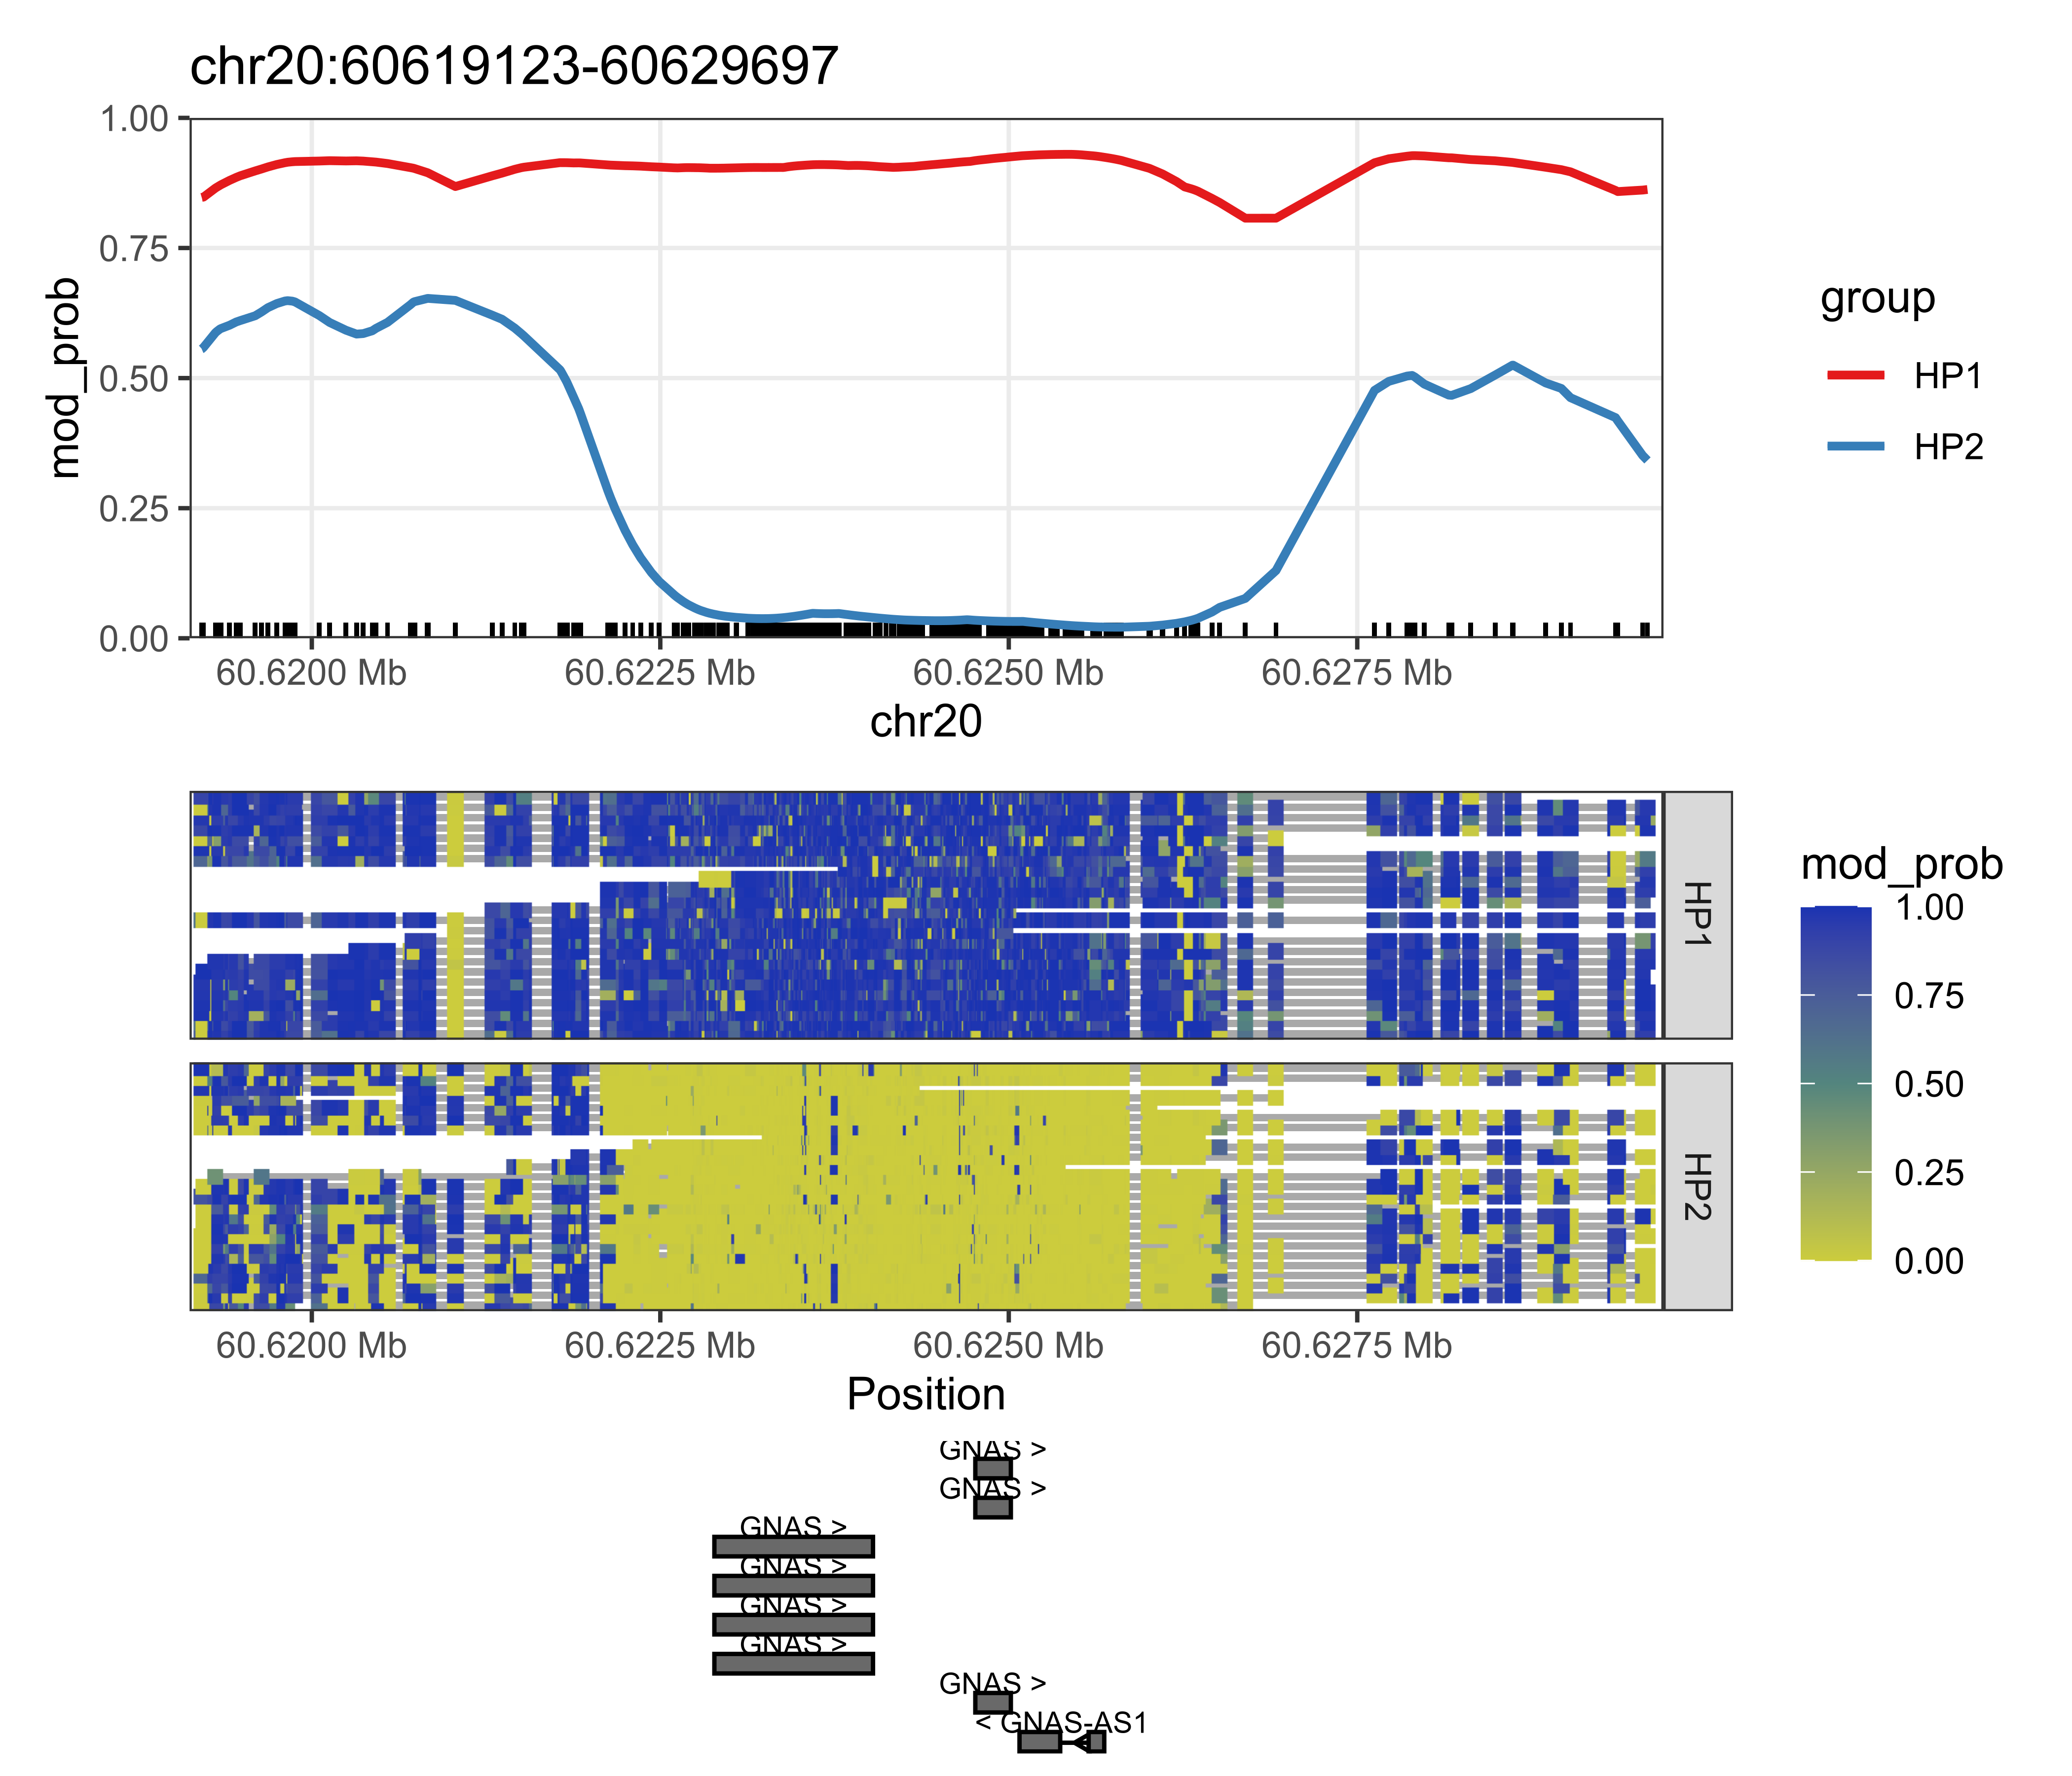

In [6]:
show('fig2c_human_GNAS.png')

## Figure 2c - the same window, the agent's run

Same script, same window, the other arm's reads.

In [7]:
%%R
## scripts/paper/modbam_region_plot.R, run as R. Edit any line and re-run the cell.

#!/usr/bin/env Rscript
rm(list = ls())

library(argparser)
library(NanoMethViz)
library(dplyr)
library(rtracklayer)
library(GenomicRanges)

# ---------------------------------------------------------------------------
# NanoMethViz region plot for two ModBAM files (HP1 vs HP2) on T2T (hs1) coords
#
# Example:
# Rscript modbam_nanomethviz_hp_region_plot.R \
#   --hp1_bam /path/to/HP1.bam \
#   --hp2_bam /path/to/HP2.bam \
#   --chr chr11 --start 118453794 --end 118548121 \
#   --flank 5000 --tagname KMT2A --svg
# ---------------------------------------------------------------------------
parser <- arg_parser(
	"Plot NanoMethViz methylation tracks at a user-defined region from two ModBAM files (HP1, HP2)."
)

parser <- add_argument(parser, "--hp1_bam", help = "HP1 ModBAM file path", type = "character")
parser <- add_argument(parser, "--hp2_bam", help = "HP2 ModBAM file path", type = "character")
parser <- add_argument(parser, "--hp1_name", help = "HP1 sample name in plot", type = "character", default = "HP1")
parser <- add_argument(parser, "--hp2_name", help = "HP2 sample name in plot", type = "character", default = "HP2")
parser <- add_argument(parser, "--chr", help = "Chromosome (T2T, e.g. chr11)", type = "character")
parser <- add_argument(parser, "--start", help = "Region start coordinate", type = "integer")
parser <- add_argument(parser, "--end", help = "Region end coordinate", type = "integer")
parser <- add_argument(parser, "--flank", help = "Flanking bp added to start/end", type = "integer", default = 2000)
parser <- add_argument(
	parser, "--gtf_file", help = "T2T GTF annotation file (hs1.ncbiRefSeq.gtf)",
	type = "character",
	default = "/project2/sli68423_1316/users/yang/reference/chm13v2.0/genes/hs1.ncbiRefSeq.gtf"
)
parser <- add_argument(parser, "--wdir", help = "Working directory", type = "character", default = ".")
parser <- add_argument(parser, "--outdir", help = "Output directory for plots", type = "character", default = "modbam_plots")
parser <- add_argument(parser, "--outfn_prefix", help = "Output file name prefix", type = "character", default = "nanomethviz_hp_region")
parser <- add_argument(parser, "--tagname", help = "Tag appended to output file name", type = "character", default = "")
parser <- add_argument(parser, "--fig_w", help = "Figure width (inches)", type = "integer", default = 8)
parser <- add_argument(parser, "--fig_h", help = "Figure height (inches)", type = "integer", default = 7)
parser <- add_argument(parser, "--avg_method", help = "Aggregation method: mean or median", type = "character", default = "mean")
parser <- add_argument(parser, "--smoothing_window", help = "Smoothing window (bp)", type = "integer", default = 2000)
parser <- add_argument(parser, "--heatmap_subsample", help = "Heatmap subsample size", type = "integer", default = 200)
parser <- add_argument(parser, "--hp1_color", help = "HP1 track color", type = "character", default = "#E41A1C")
parser <- add_argument(parser, "--hp2_color", help = "HP2 track color", type = "character", default = "#377EB8")
parser <- add_argument(parser, "--svg", help = "Also save SVG output", flag = TRUE)
parser <- add_argument(parser, "--png", help = "Also save PNG output", flag = TRUE)
parser <- add_argument(parser, "--png_dpi", help = "PNG resolution (dpi)", type = "integer", default = 600)
parser <- add_argument(parser, "--no_gene_anno", help = "Hide gene annotation track", flag = TRUE)

## parse_args given its arguments directly; a notebook has no command line.
args <- parse_args(parser, c("--hp1_bam", file.path(Sys.getenv("LV_DATA"), "gnas_arms/fig2c_ont_agent_HP1.bam"), "--hp2_bam", file.path(Sys.getenv("LV_DATA"), "gnas_arms/fig2c_ont_agent_HP2.bam"), "--chr", "chr20", "--start", "60622123", "--end", "60626697", "--flank", "3000", "--gtf_file", file.path(Sys.getenv("LV_DATA"), "icr_bam/hs1.ncbiRefSeq.icr.gtf"), "--outdir", Sys.getenv("LV_OUT"), "--outfn_prefix", "fig2c_agent", "--tagname", "GNAS", "--fig_w", "7", "--fig_h", "6", "--png"))
str(args)

if (args$start >= args$end) {
	stop("--start must be less than --end")
}

required_files <- c(args$hp1_bam, args$hp2_bam, args$gtf_file)
missing_files <- required_files[!file.exists(required_files)]
if (length(missing_files) > 0) {
	stop("Missing input file(s):\n", paste(missing_files, collapse = "\n"))
}

if (!dir.exists(args$wdir)) {
	stop("wdir not found: ", args$wdir)
}
setwd(args$wdir)

outdir <- args$outdir
if (!dir.exists(outdir)) {
	dir.create(outdir, recursive = TRUE, showWarnings = FALSE)
}

# ---------------------------------------------------------------------------
# T2T exon annotation (shared style with prior NanoMethViz scripts)
# ---------------------------------------------------------------------------
get_all_exon <- function(gtf_df) {
	exon_df <- gtf_df[gtf_df$type == "exon", ]
	exon_table <- exon_df %>%
		dplyr::select(
			gene_id = gene_id,
			chr = seqnames,
			strand = strand,
			start = start,
			end = end,
			transcript_id = transcript_id,
			symbol = gene_name
		)
	tibble::as_tibble(exon_table)
}

get_region_exons <- function(exon_tibble, chr, region_start, region_end) {
	region_gr <- GRanges(
		seqnames = chr,
		ranges = IRanges(start = region_start, end = region_end)
	)
	exon_gr <- GRanges(
		seqnames = exon_tibble$chr,
		ranges = IRanges(start = exon_tibble$start, end = exon_tibble$end)
	)
	hits <- findOverlaps(exon_gr, region_gr)
	tibble::as_tibble(exon_tibble[queryHits(hits), , drop = FALSE])
}

gtf_data <- import(args$gtf_file)
gtf_df <- as.data.frame(gtf_data)

region_start <- max(1L, args$start - args$flank)
region_end <- args$end + args$flank
exon_tibble <- get_region_exons(
	get_all_exon(gtf_df),
	chr = args$chr,
	region_start = region_start,
	region_end = region_end
)

if (nrow(exon_tibble) == 0) {
	warning("No exons overlap region ", args$chr, ":", region_start, "-", region_end)
}

# ---------------------------------------------------------------------------
# Build ModBAM NanoMethViz object (HP1 vs HP2)
# ---------------------------------------------------------------------------
sample_names <- c(args$hp1_name, args$hp2_name)
bam_files <- c(args$hp1_bam, args$hp2_bam)
group_names <- sample_names

mbr <- ModBamResult(
	methy = ModBamFiles(
		samples = sample_names,
		bam_files
	),
	samples = data.frame(
		sample = sample_names,
		group = group_names,
		stringsAsFactors = FALSE
	),
	exons = exon_tibble
)

grange <- GRanges(
	seqnames = args$chr,
	ranges = IRanges(start = region_start, end = region_end)
)

palette1 <- ggplot2::scale_colour_manual(
	values = stats::setNames(c(args$hp1_color, args$hp2_color), sample_names)
)

show_gene_anno <- !args$no_gene_anno

np1 <- plot_grange(
	mbr,
	grange,
	palette = palette1,
	avg_method = args$avg_method,
	smoothing_window = args$smoothing_window,
	heatmap_subsample = args$heatmap_subsample,
	gene_anno = show_gene_anno
)

# ---------------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------------
if (nzchar(args$tagname)) {
	out_prefix <- sprintf("%s_%s", args$outfn_prefix, args$tagname)
} else {
	out_prefix <- sprintf(
		"%s_%s_%d_%d",
		args$outfn_prefix,
		gsub("^chr", "", args$chr),
		args$start,
		args$end
	)
}

save_plot <- function(device_fn, width, height, ...) {
	graphics.off()
	device_fn(file.path(outdir, outfn), width = width, height = height, ...)
	print(np1)
	dev.off()
}

outfn <- sprintf("%s.pdf", out_prefix)
save_plot(pdf, args$fig_w, args$fig_h)
cat("Saved to", file.path(outdir, outfn), "\n")

if (args$svg) {
	outfn <- sprintf("%s.svg", out_prefix)
	save_plot(svg, args$fig_w, args$fig_h)
	cat("Saved to", file.path(outdir, outfn), "\n")
}

if (args$png) {
	outfn <- sprintf("%s.png", out_prefix)
	save_plot(
		png,
		args$fig_w,
		args$fig_h,
		units = "in",
		res = args$png_dpi
	)
	cat("Saved to", file.path(outdir, outfn), "\n")
}

rdata_fn <- file.path(outdir, sprintf("%s.RData", out_prefix))
save.image(rdata_fn)
cat("Saved workspace to", rdata_fn, "\n")

cat("### Done\n")

## The magic closes a device when the cell ends, and the script's
## graphics.off() already closed it. Give it one to close.
grDevices::pdf(NULL)


List

 of 

27

$ 

:

...

Saved to

./figures/notebook/fig2c_agent_GNAS.png

Saved workspace to

./figures/notebook/fig2c_agent_GNAS.RData

### Done


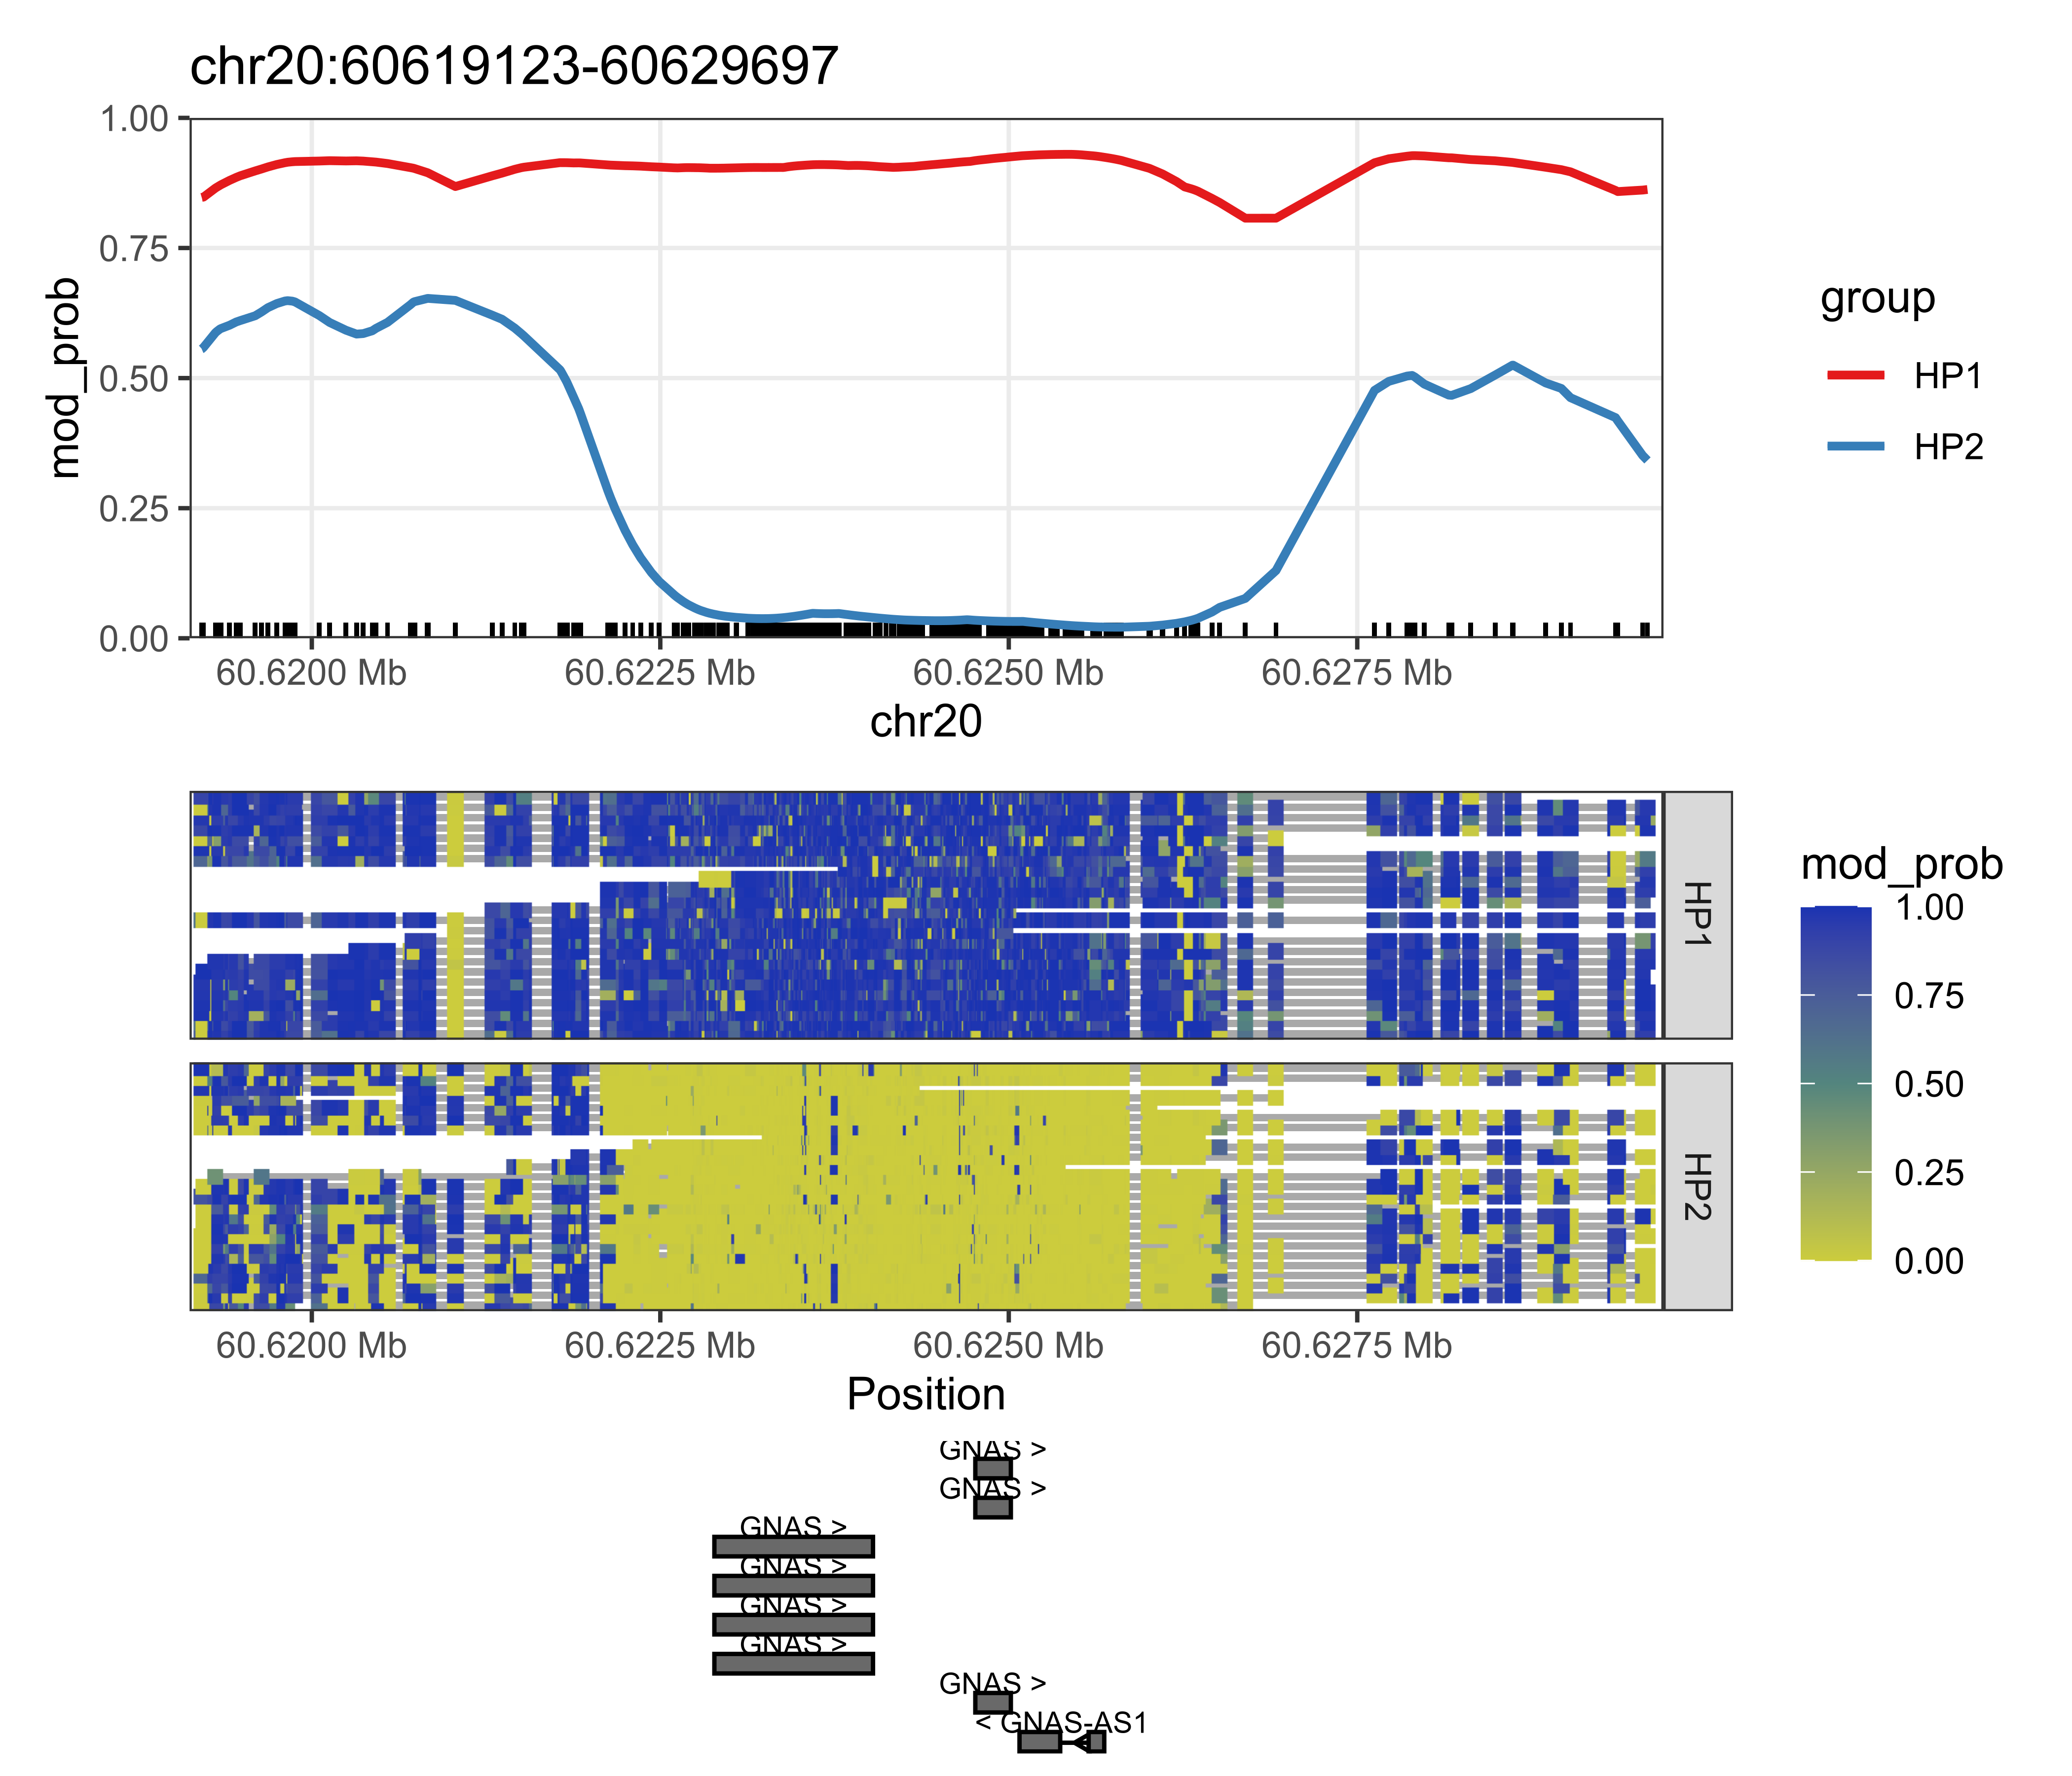

In [8]:
show('fig2c_agent_GNAS.png')

## Figure 2a - what the two arms were given

In the paper this panel is native PowerPoint text, so the commands stay selectable. There is no image to regenerate; its content is below, from the same records.

In [9]:
import json
from IPython.display import Markdown, display

rec = json.load(open("../data/fig2/a_calling_run_record.json"))
cmd = open("../data/fig2/a_calling_human_command.txt").read().strip()

display(Markdown(f"**What the expert ran**\n\n```bash\n{cmd}\n```"))
display(Markdown(f"**What the agent was asked**\n\n> {rec.get('prompt') or rec.get('sentence') or '(see the record)'}"))
chain = rec.get("tool_chain") or [s.get("tool") for s in rec.get("steps", []) if s.get("tool")]
if chain:
    display(Markdown("**The tools it chose**\n\n" + "\n".join(f"{i}. `{t}`" for i, t in enumerate(chain, 1))))

**What the expert ran**

```bash
nextflow -log "$ROOT/launch/nextflow.log" run "$REPO" \
    -profile singularity,hpc \
    --dsname hg002_ont_chr20_up \
    --input "$ROOT/input" \
    --genome $HOME_DIR/reference/chm13v2.0 \
    --gpu_queue lilab --cpu_queue lilab --account sli68423_1316 \
    --gpu_gresOptions 'gpu:1' \
    --containerOptions '--nv -B /scratch1 -B /project2 -B $LONGVERSE/hpc_test/analysis_claude/agent_benchmark/ps_shim.sh:/usr/bin/ps' \
    --chrSet chr20 --ctg_name chr20 \
    --cpu_memory 350.GB --cpu_processors 16 --cpu_time 14.d --gpu_time 14.d \
    --dorado_basecall_model dna_r10.4.1_e8.2_400bps_hac@v4.1.0 \
    --dorado_methcall_model dna_r10.4.1_e8.2_400bps_hac@v4.1.0_5mCG_5hmCG@v2 \
    -with-trace "$ROOT/launch/trace.txt" \
    -with-report "$ROOT/launch/report.html" \
    -with-timeline "$ROOT/launch/timeline.html" \
    -with-dag "$ROOT/launch/dag.html"
```

**What the agent was asked**

> (see the record)